## 1.Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Loading the Dataset

In [10]:
df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")

## 3.Check Information

In [4]:
print(df.shape)

(4000, 28)


In [5]:
print(df.head())

   Farm_ID           State  District    Crop  Season  Farm_Area_Hectares  \
0  SF10001  Andhra Pradesh    Rajkot   Wheat  Kharif                0.53   
1  SF10002     Maharashtra  Nalgonda   Maize  Kharif                6.53   
2  SF10003       Telangana  Warangal  Pulses    Rabi                4.86   
3  SF10004       Telangana    Indore    Rice  Kharif                4.50   
4  SF10005       Karnataka  Ludhiana   Maize    Zaid                4.21   

   Rainfall_mm  Avg_Temperature_C  Humidity_pct  Sunlight_Hours_Day  ...  \
0        486.4               24.3          69.1                 5.8  ...   
1        855.4               25.7          78.4                 5.1  ...   
2        455.6               23.9          56.4                10.3  ...   
3        753.2               29.7          65.2                 6.3  ...   
4        101.6               34.1          55.2                 6.5  ...   

   Seed_Quality_Score  Yield_Tonnes_Ha  Production_Tonnes  \
0                0.76    

In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [7]:
print(df.columns)

Index(['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares',
       'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
       'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha',
       'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method',
       'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
       'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne',
       'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3',
       'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct'],
      dtype='object')


## 4.Check Missing Values

In [8]:
print(df.isnull().sum())

Farm_ID                           0
State                             0
District                          0
Crop                              0
Season                            0
Farm_Area_Hectares                0
Rainfall_mm                      48
Avg_Temperature_C                 0
Humidity_pct                      0
Sunlight_Hours_Day                0
Soil_pH                           0
Soil_Moisture_pct                40
Nitrogen_kg_ha                    0
Phosphorus_kg_ha                  0
Potassium_kg_ha                   0
Irrigation_Method                 0
Fertilizer_kg_ha                  0
Pesticide_Litre_ha                0
Seed_Quality_Score                0
Yield_Tonnes_Ha                  32
Production_Tonnes                 0
Market_Price_INR_Tonne            0
Total_Cost_INR                    0
Revenue_INR                       0
Profit_INR                        0
Water_Used_m3                     0
Water_Efficiency_t_per_1000m3     0
Disease_Pest_Risk_pct       

In [9]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


## 5.Understanding Categorical Variables

In [15]:
print("Seasons:",df['Season'].unique())
print("\nCrops:",df['Crop'].unique())
print("\nStates:",df['State'].unique())
print("\nIrrigation Methods:",df['Irrigation_Method'].unique())

Seasons: ['Kharif' 'Rabi' 'Zaid']

Crops: ['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

States: ['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']

Irrigation Methods: ['Drip' 'Flood' 'Rainfed' 'Sprinkler']


## 6.Visualization

In [16]:
print(df['Season'].value_counts())

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


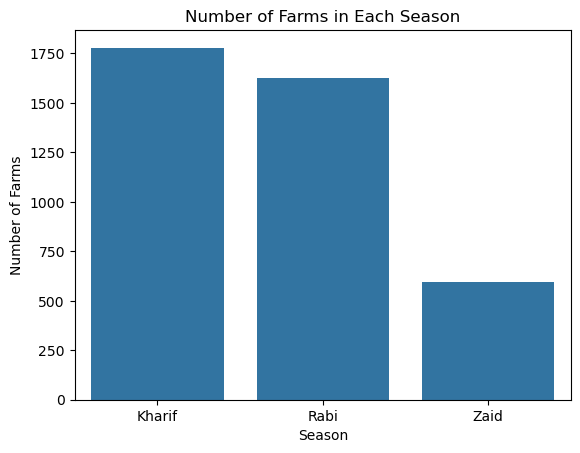

In [17]:
sns.countplot(data=df, x='Season')

plt.title("Number of Farms in Each Season")
plt.xlabel("Season")
plt.ylabel("Number of Farms")
plt.show()

In [18]:
print(df['Crop'].value_counts())

Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64


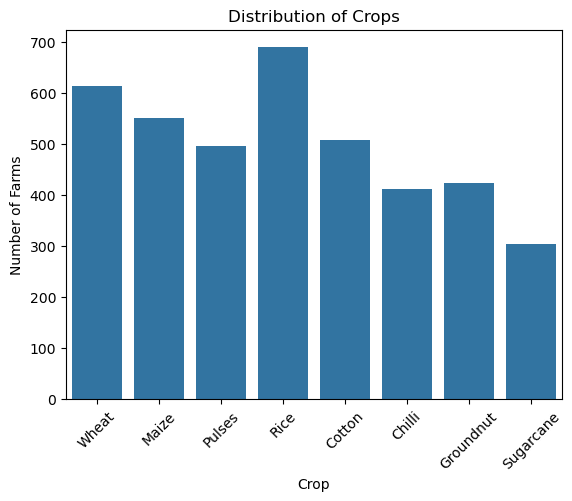

In [19]:
sns.countplot(data=df, x='Crop')

plt.title("Distribution of Crops")
plt.xlabel("Crop")
plt.ylabel("Number of Farms")
plt.xticks(rotation=45)
plt.show()

In [20]:
print(df['State'].value_counts())

State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64


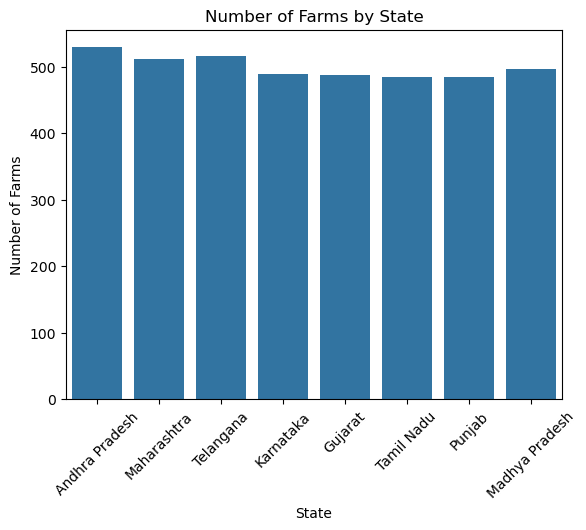

In [21]:
sns.countplot(data=df, x='State')

plt.title("Number of Farms by State")
plt.xlabel("State")
plt.ylabel("Number of Farms")
plt.xticks(rotation=45)
plt.show()

## 6.Questions Raised and Insights

## a.How does agricultural performance vary across seasons?

Average Yield

In [22]:
season_yield = df.groupby('Season')['Yield_Tonnes_Ha'].mean()

print(season_yield)

Season
Kharif    5.643973
Rabi      5.080498
Zaid      4.665942
Name: Yield_Tonnes_Ha, dtype: float64


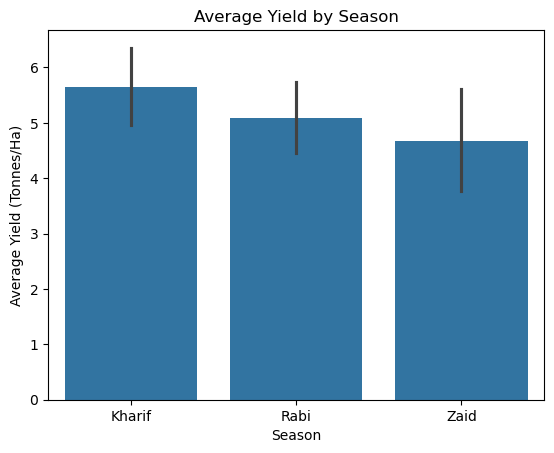

In [23]:
sns.barplot(data=df, x='Season', y='Yield_Tonnes_Ha')
plt.title("Average Yield by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.show()

Production Across Seasons

In [24]:
season_production = df.groupby('Season')['Production_Tonnes'].mean()
print(season_production)

Season
Kharif    46.311192
Rabi      41.486712
Zaid      38.886111
Name: Production_Tonnes, dtype: float64


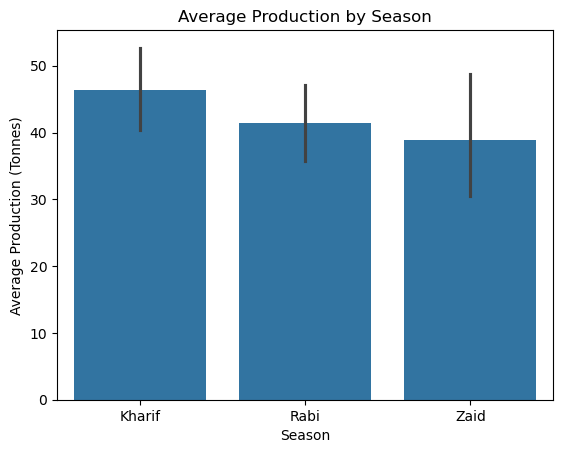

In [25]:
sns.barplot(data=df, x='Season', y='Production_Tonnes')
plt.title("Average Production by Season")
plt.xlabel("Season")
plt.ylabel("Average Production (Tonnes)")
plt.show()

Revenue Across Seasons

In [26]:
season_revenue = df.groupby('Season')['Revenue_INR'].mean()
print(season_revenue)

Season
Kharif    710719.055649
Rabi      601526.048556
Zaid      519171.904040
Name: Revenue_INR, dtype: float64


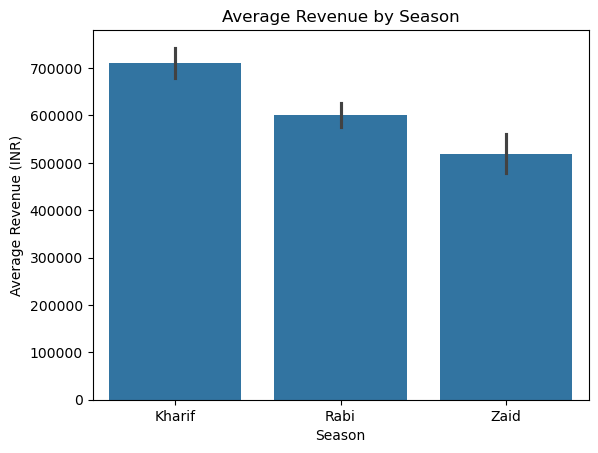

In [27]:
sns.barplot(data=df, x='Season', y='Revenue_INR')
plt.title("Average Revenue by Season")
plt.xlabel("Season")
plt.ylabel("Average Revenue (INR)")
plt.show()

Profit Across Seasons

In [30]:
season_profit = df.groupby('Season')['Profit_INR'].mean()
print(season_profit)

Season
Kharif    178914.647555
Rabi       87689.470191
Zaid      -24804.824916
Name: Profit_INR, dtype: float64


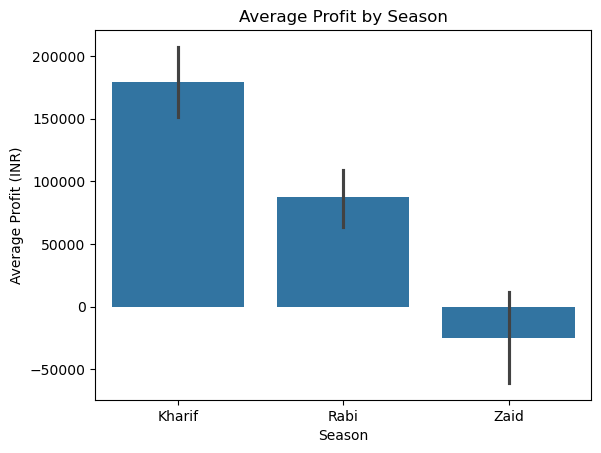

In [31]:
sns.barplot(data=df, x='Season', y='Profit_INR')
plt.title("Average Profit by Season")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.show()

Compare Yield Distribution

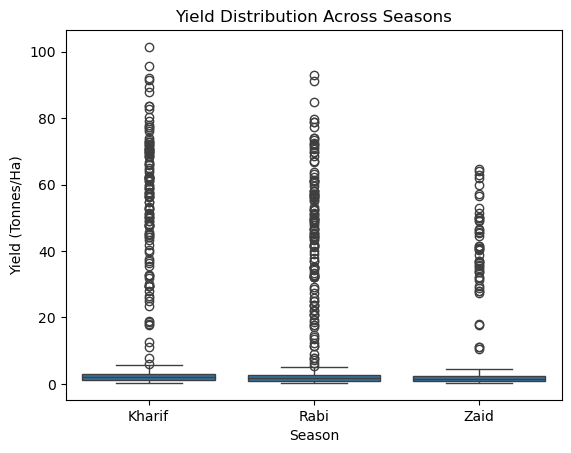

In [32]:
sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha')
plt.title("Yield Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()

Rainfall Across Seasons

In [33]:
rainfall = df.groupby('Season')['Rainfall_mm'].mean()
print(rainfall)

Season
Kharif    852.084205
Rabi      436.000124
Zaid      299.421784
Name: Rainfall_mm, dtype: float64


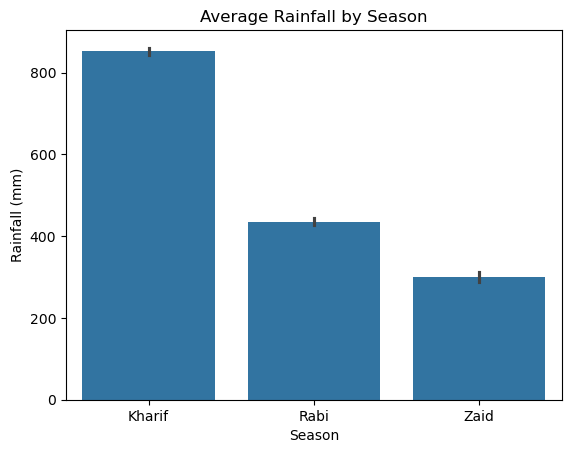

In [34]:
sns.barplot(data=df, x='Season', y='Rainfall_mm')
plt.title("Average Rainfall by Season")
plt.xlabel("Season")
plt.ylabel("Rainfall (mm)")
plt.show()

In [35]:
soil_moisture = df.groupby('Season')['Soil_Moisture_pct'].mean()
print(soil_moisture)

Season
Kharif    31.198410
Rabi      24.050620
Zaid      19.170085
Name: Soil_Moisture_pct, dtype: float64


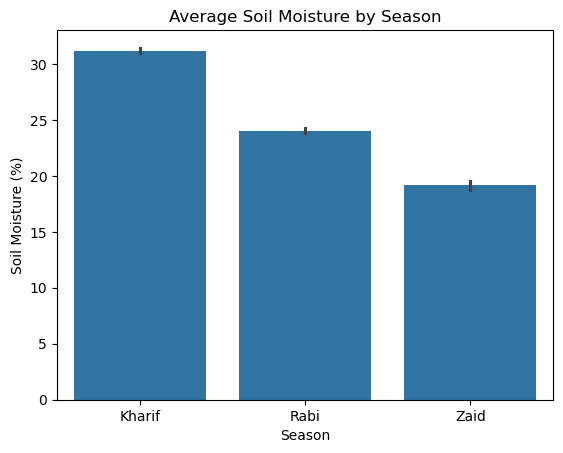

In [36]:
sns.barplot(data=df, x='Season', y='Soil_Moisture_pct')
plt.title("Average Soil Moisture by Season")
plt.xlabel("Season")
plt.ylabel("Soil Moisture (%)")
plt.show()

Temperature Across Seasons

In [37]:
temperature = df.groupby('Season')['Avg_Temperature_C'].mean()
print(temperature)

Season
Kharif    28.454019
Rabi      23.489183
Zaid      31.042088
Name: Avg_Temperature_C, dtype: float64


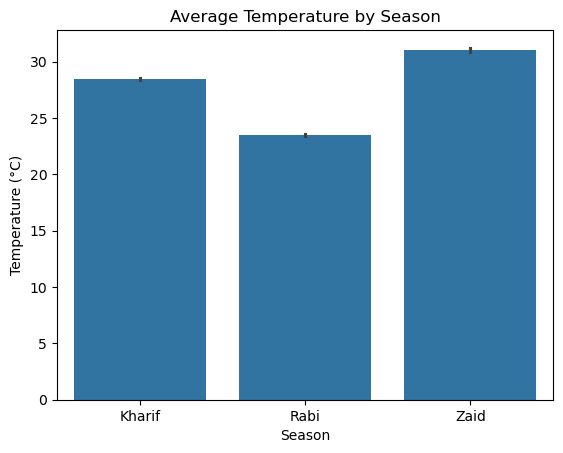

In [38]:
sns.barplot(data=df, x='Season', y='Avg_Temperature_C')
plt.title("Average Temperature by Season")
plt.xlabel("Season")
plt.ylabel("Temperature (°C)")
plt.show()

Humidity Across Seasons

In [40]:
humidity = df.groupby('Season')['Humidity_pct'].mean()
print(humidity)

Season
Kharif    71.812591
Rabi      57.893178
Zaid      52.012121
Name: Humidity_pct, dtype: float64


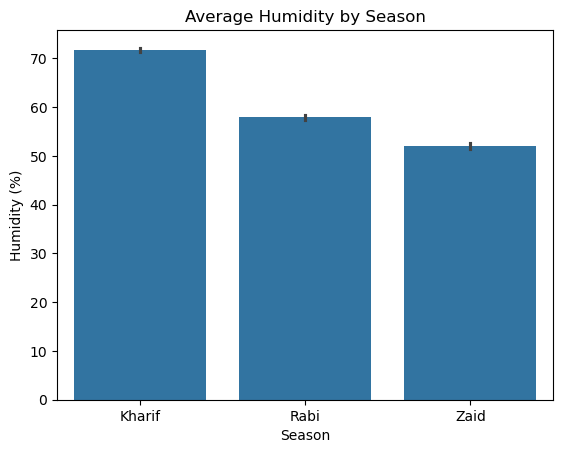

In [41]:
sns.barplot(data=df, x='Season', y='Humidity_pct')
plt.title("Average Humidity by Season")
plt.xlabel("Season")
plt.ylabel("Humidity (%)")
plt.show()

## b. How does resource usage vary across seasons?

Water Usage

In [ ]:
water = df.groupby('Season')['Water_Used_m3'].mean()
print(water)

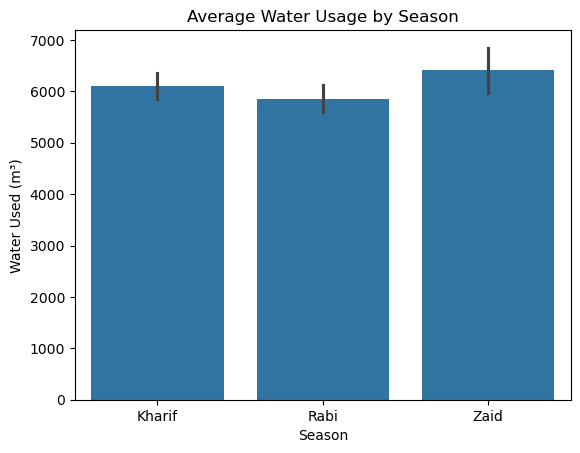

In [43]:
sns.barplot(data=df, x='Season', y='Water_Used_m3')
plt.title("Average Water Usage by Season")
plt.xlabel("Season")
plt.ylabel("Water Used (m³)")
plt.show()

Fertilizer Usage

In [44]:
fertilizer = df.groupby('Season')['Fertilizer_kg_ha'].mean()
print(fertilizer)

Season
Kharif    187.077965
Rabi      185.407068
Zaid      184.638047
Name: Fertilizer_kg_ha, dtype: float64


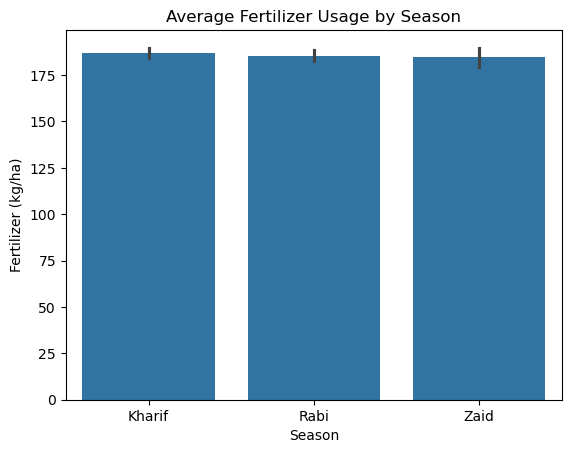

In [45]:
sns.barplot(data=df, x='Season', y='Fertilizer_kg_ha')
plt.title("Average Fertilizer Usage by Season")
plt.xlabel("Season")
plt.ylabel("Fertilizer (kg/ha)")
plt.show()

Pesticide Usage

In [46]:
pesticide = df.groupby('Season')['Pesticide_Litre_ha'].mean()
print(pesticide)

Season
Kharif    5.079747
Rabi      5.024690
Zaid      5.171212
Name: Pesticide_Litre_ha, dtype: float64


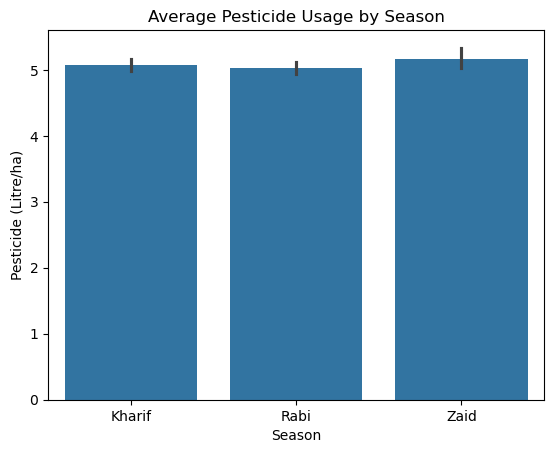

In [47]:
sns.barplot(data=df, x='Season', y='Pesticide_Litre_ha')
plt.title("Average Pesticide Usage by Season")
plt.xlabel("Season")
plt.ylabel("Pesticide (Litre/ha)")
plt.show()

Water Efficiency

In [48]:
water_efficiency = df.groupby('Season')['Water_Efficiency_t_per_1000m3'].mean()
print(water_efficiency)

Season
Kharif    5.891834
Rabi      5.186122
Zaid      4.413239
Name: Water_Efficiency_t_per_1000m3, dtype: float64


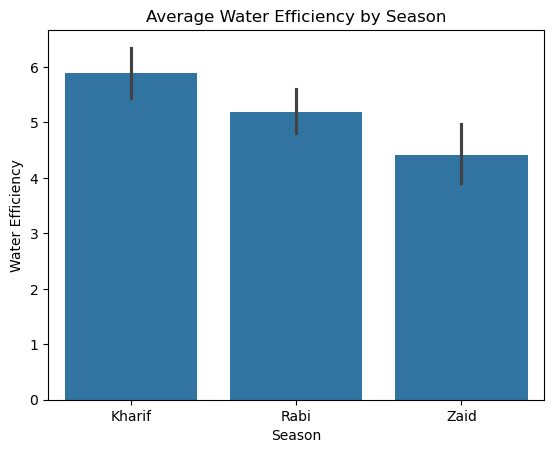

In [49]:
sns.barplot(data=df, x='Season', y='Water_Efficiency_t_per_1000m3')
plt.title("Average Water Efficiency by Season")
plt.xlabel("Season")
plt.ylabel("Water Efficiency")
plt.show()

## c.What are the economic differences across seasons?

Cost

In [50]:
cost = df.groupby('Season')['Total_Cost_INR'].mean()
print(cost)

Season
Kharif    531804.408094
Rabi      513836.578365
Zaid      543976.728956
Name: Total_Cost_INR, dtype: float64


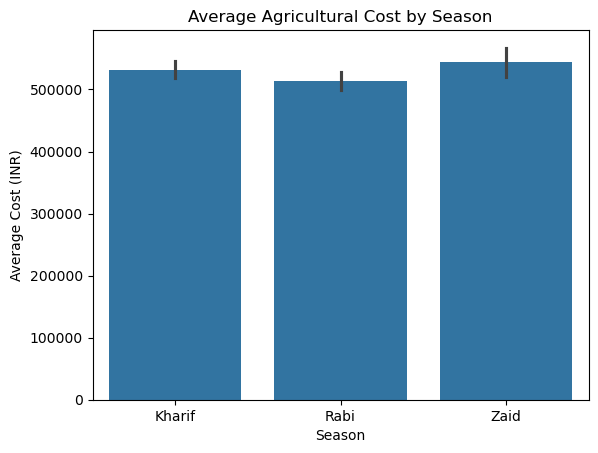

In [51]:
sns.barplot(data=df, x='Season', y='Total_Cost_INR')

plt.title("Average Agricultural Cost by Season")
plt.xlabel("Season")
plt.ylabel("Average Cost (INR)")
plt.show()

In [61]:
#revenue
revenue = df.groupby('Season')['Revenue_INR'].mean()
print(revenue)

Season
Kharif    710719.055649
Rabi      601526.048556
Zaid      519171.904040
Name: Revenue_INR, dtype: float64


In [53]:
profit = df.groupby('Season')['Profit_INR'].mean()
print(profit)

Season
Kharif    178914.647555
Rabi       87689.470191
Zaid      -24804.824916
Name: Profit_INR, dtype: float64


## d. Which crops perform best in different seasons?

In [54]:
crop_season = df.groupby(
    ['Crop', 'Season']
)['Yield_Tonnes_Ha'].mean()
print(crop_season)

Crop       Season
Chilli     Kharif     1.731413
           Rabi       1.461615
           Zaid       1.177742
Cotton     Kharif     1.372804
           Rabi       1.192915
           Zaid       0.951648
Groundnut  Kharif     1.483646
           Rabi       1.221445
           Zaid       1.037778
Maize      Kharif     2.966410
           Rabi       2.614913
           Zaid       2.297590
Pulses     Kharif     1.036063
           Rabi       0.871887
           Zaid       0.652131
Rice       Kharif     2.707621
           Rabi       2.333680
           Zaid       1.900490
Sugarcane  Kharif    53.459120
           Rabi      43.940394
           Zaid      38.423922
Wheat      Kharif     2.255430
           Rabi       2.058814
           Zaid       1.748588
Name: Yield_Tonnes_Ha, dtype: float64


In [55]:
crop_season_table = df.pivot_table(
    values='Yield_Tonnes_Ha',
    index='Crop',
    columns='Season',
    aggfunc='mean'
)
print(crop_season_table)

Season        Kharif       Rabi       Zaid
Crop                                      
Chilli      1.731413   1.461615   1.177742
Cotton      1.372804   1.192915   0.951648
Groundnut   1.483646   1.221445   1.037778
Maize       2.966410   2.614913   2.297590
Pulses      1.036063   0.871887   0.652131
Rice        2.707621   2.333680   1.900490
Sugarcane  53.459120  43.940394  38.423922
Wheat       2.255430   2.058814   1.748588


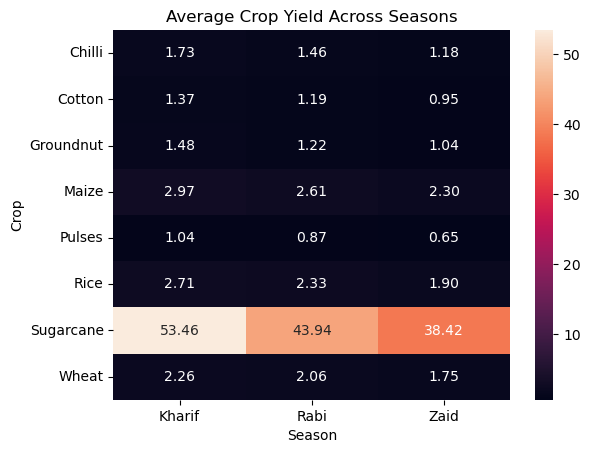

In [56]:
sns.heatmap(crop_season_table, annot=True, fmt='.2f')
plt.title("Average Crop Yield Across Seasons")
plt.xlabel("Season")
plt.ylabel("Crop")
plt.show()

## e.How does agricultural performance differ across states?

In [57]:
state_performance = df.groupby('State')['Yield_Tonnes_Ha'].mean()
print(state_performance)

State
Andhra Pradesh    4.650781
Gujarat           5.699586
Karnataka         5.734493
Madhya Pradesh    5.029654
Maharashtra       5.030333
Punjab            6.121116
Tamil Nadu        4.901247
Telangana         5.076810
Name: Yield_Tonnes_Ha, dtype: float64


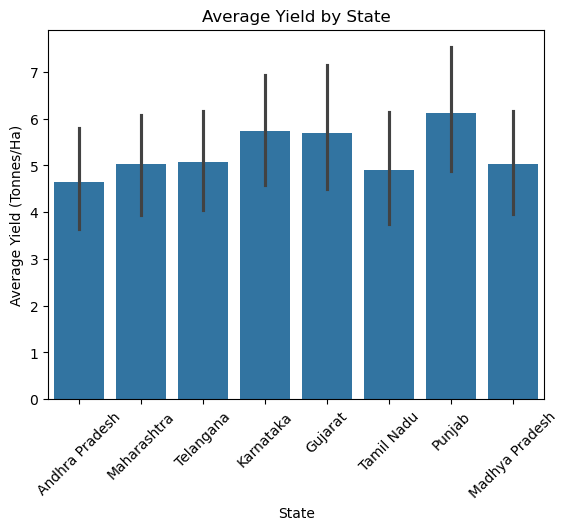

In [58]:
sns.barplot(
    data=df,
    x='State',
    y='Yield_Tonnes_Ha'
)
plt.title("Average Yield by State")
plt.xlabel("State")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=45)
plt.show()

State and Season Comparison

In [59]:
state_season = df.pivot_table(
    values='Yield_Tonnes_Ha',
    index='State',
    columns='Season',
    aggfunc='mean'
)
print(state_season)

Season            Kharif      Rabi      Zaid
State                                       
Andhra Pradesh  5.693431  3.488069  4.480238
Gujarat         6.338416  5.517245  4.101970
Karnataka       6.523689  4.609655  6.623243
Madhya Pradesh  6.004133  3.800000  5.539194
Maharashtra     5.447014  5.501927  2.285352
Punjab          4.100633  8.609355  5.909610
Tamil Nadu      5.520534  4.555539  4.097746
Telangana       5.568798  4.831649  4.278333


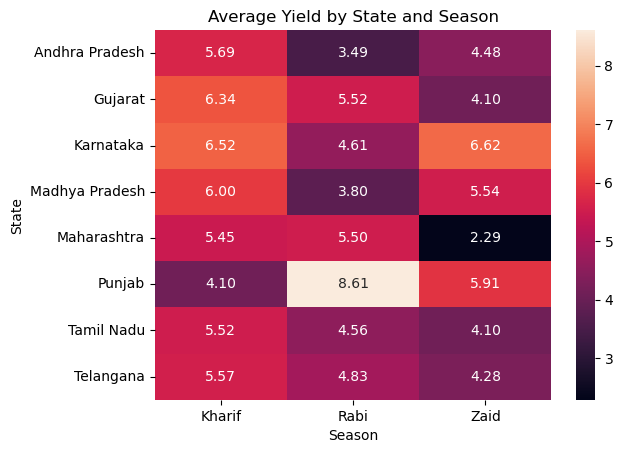

In [60]:
sns.heatmap(state_season, annot=True, fmt='.2f')
plt.title("Average Yield by State and Season")
plt.xlabel("Season")
plt.ylabel("State")
plt.show()

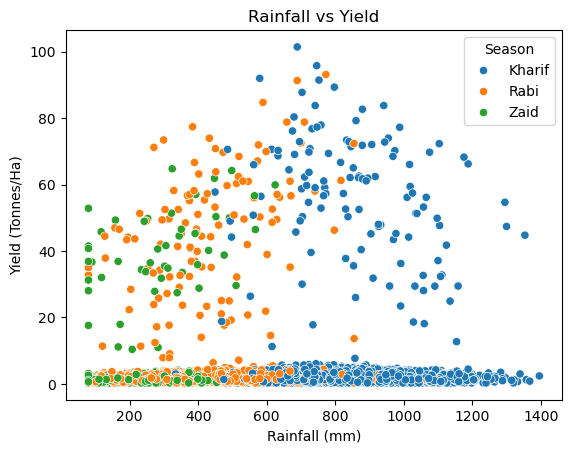

In [62]:
# Rainfall vs Yield
sns.scatterplot(data=df, x='Rainfall_mm', y='Yield_Tonnes_Ha', hue='Season')
plt.title("Rainfall vs Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()

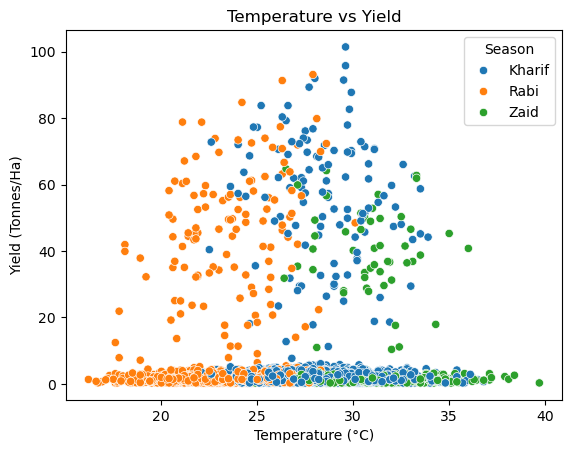

In [63]:
# Temperature vs Yield

sns.scatterplot(data=df, x='Avg_Temperature_C', y='Yield_Tonnes_Ha', hue='Season')
plt.title("Temperature vs Yield")
plt.xlabel("Temperature (°C)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()

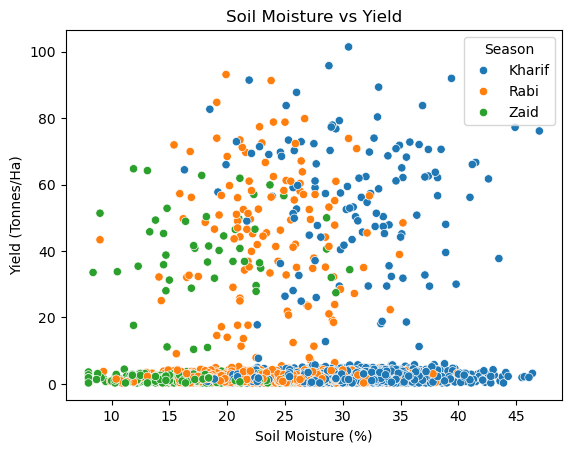

In [65]:
# Soil Moisture vs Yield

sns.scatterplot(data=df, x='Soil_Moisture_pct', y='Yield_Tonnes_Ha', hue='Season')
plt.title("Soil Moisture vs Yield")
plt.xlabel("Soil Moisture (%)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()

Calculate Environmental Correlations

In [66]:
environmental_corr = df[
    ['Rainfall_mm',
     'Avg_Temperature_C',
     'Humidity_pct',
     'Soil_Moisture_pct',
     'Sunlight_Hours_Day',
     'Yield_Tonnes_Ha']
].corr()

print(environmental_corr['Yield_Tonnes_Ha'].sort_values(ascending=False))

Yield_Tonnes_Ha       1.000000
Rainfall_mm           0.030853
Humidity_pct          0.011277
Soil_Moisture_pct     0.010210
Avg_Temperature_C     0.009349
Sunlight_Hours_Day   -0.015362
Name: Yield_Tonnes_Ha, dtype: float64


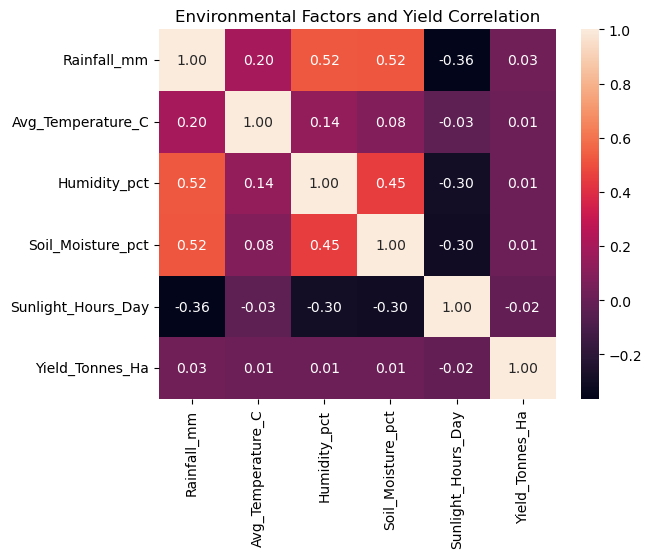

In [67]:
sns.heatmap(environmental_corr, annot=True, fmt='.2f')
plt.title("Environmental Factors and Yield Correlation")
plt.show()

## f. How are production and revenue related?

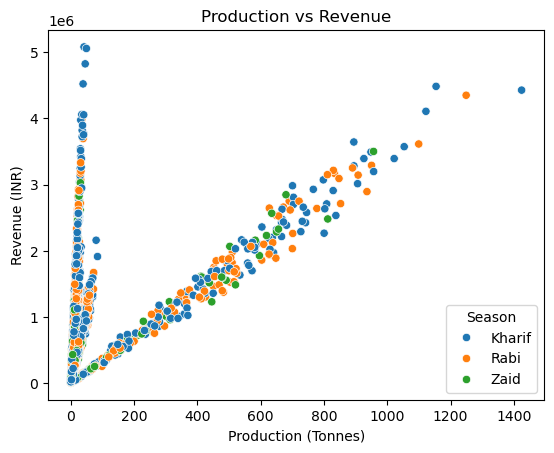

In [68]:
sns.scatterplot(data=df, x='Production_Tonnes', y='Revenue_INR', hue='Season')
plt.title("Production vs Revenue")
plt.xlabel("Production (Tonnes)")
plt.ylabel("Revenue (INR)")
plt.show()

## g.How are cost and profit related?

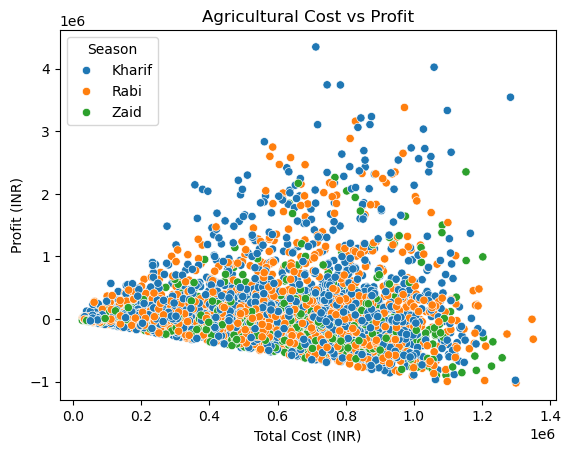

In [69]:
sns.scatterplot(data=df, x='Total_Cost_INR', y='Profit_INR', hue='Season')
plt.title("Agricultural Cost vs Profit")
plt.xlabel("Total Cost (INR)")
plt.ylabel("Profit (INR)")
plt.show()

## 7. Unusual patterns

In [71]:
disease_risk = df.groupby('Season')['Disease_Pest_Risk_pct'].mean()
print(disease_risk)

Season
Kharif    54.467903
Rabi      40.482114
Zaid      38.216667
Name: Disease_Pest_Risk_pct, dtype: float64


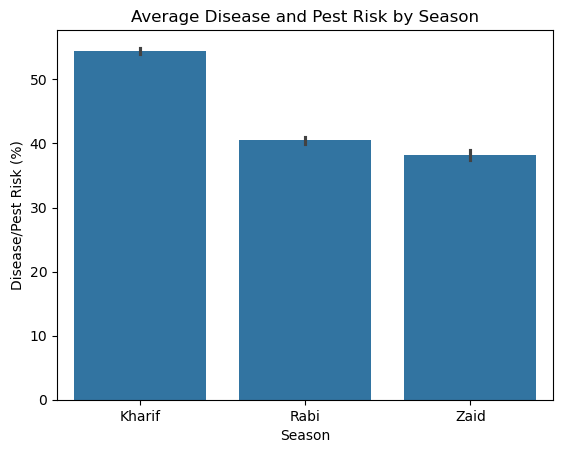

In [72]:
sns.barplot(data=df, x='Season', y='Disease_Pest_Risk_pct')
plt.title("Average Disease and Pest Risk by Season")
plt.xlabel("Season")
plt.ylabel("Disease/Pest Risk (%)")
plt.show()

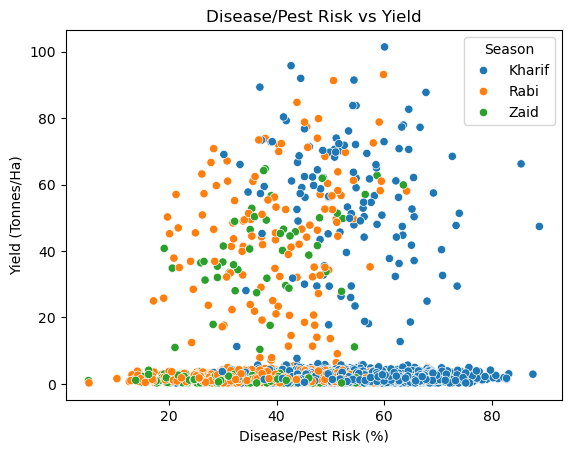

In [73]:
sns.scatterplot(
    data=df,
    x='Disease_Pest_Risk_pct',
    y='Yield_Tonnes_Ha',
    hue='Season'
)
plt.title("Disease/Pest Risk vs Yield")
plt.xlabel("Disease/Pest Risk (%)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()

## 8.Overall Correlation Analysis

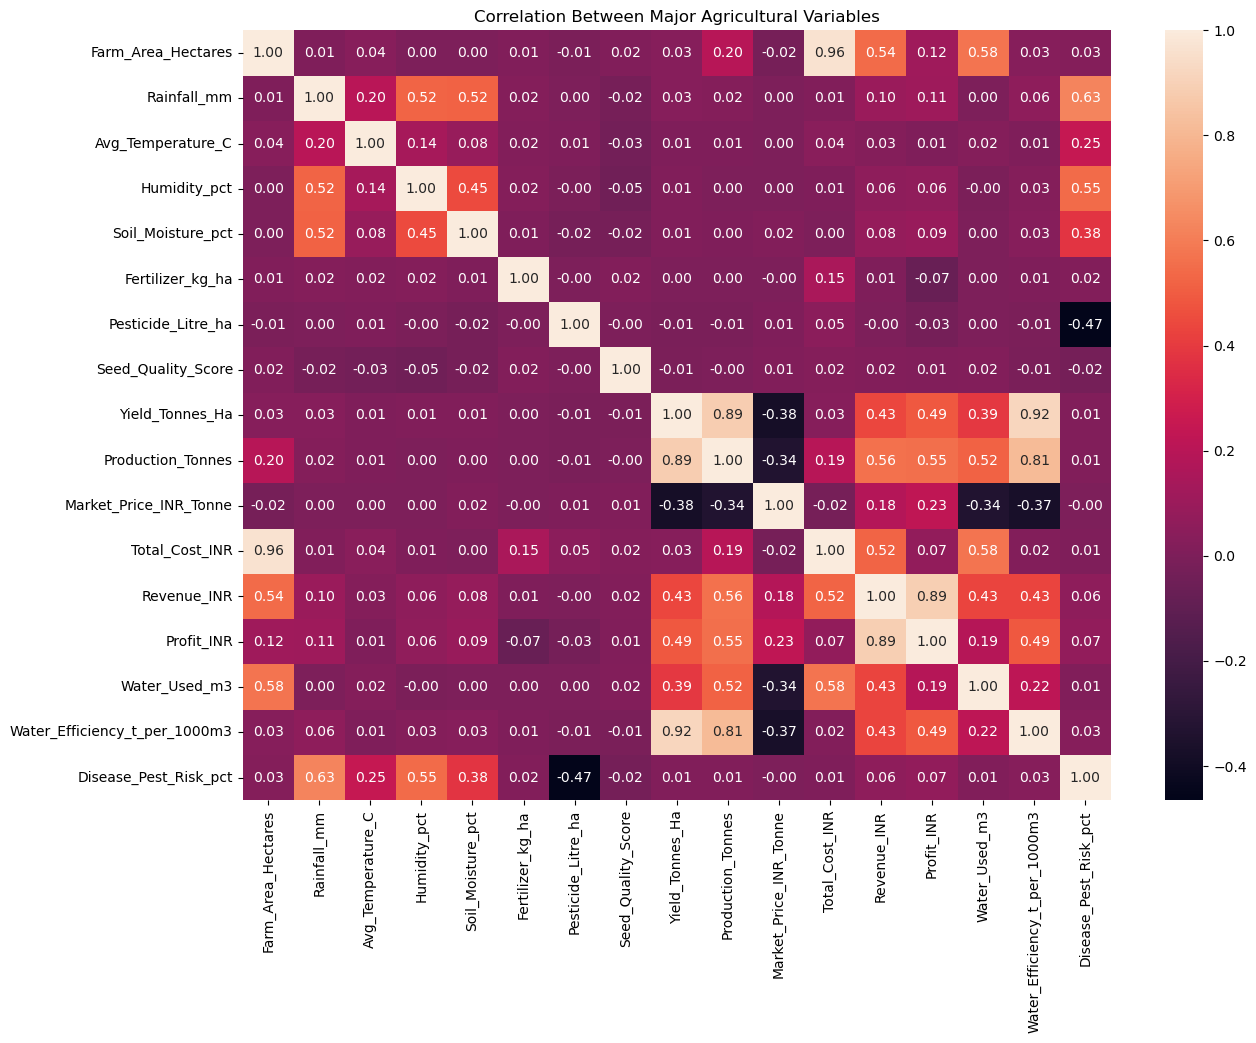

In [74]:
correlation = df[
    ['Farm_Area_Hectares','Rainfall_mm', 'Avg_Temperature_C','Humidity_pct','Soil_Moisture_pct','Fertilizer_kg_ha',
     'Pesticide_Litre_ha','Seed_Quality_Score','Yield_Tonnes_Ha','Production_Tonnes','Market_Price_INR_Tonne',
     'Total_Cost_INR','Revenue_INR','Profit_INR','Water_Used_m3','Water_Efficiency_t_per_1000m3','Disease_Pest_Risk_pct']].corr()
plt.figure(figsize=(14,10))
sns.heatmap(correlation, annot=True, fmt='.2f')
plt.title("Correlation Between Major Agricultural Variables")
plt.show()

## 9.significant observations.

In [75]:
#average yield
season_yield = df.groupby('Season')['Yield_Tonnes_Ha'].mean()
print("Average Yield by Season:")
print(season_yield)
print("Highest Yield Season:", season_yield.idxmax())
print("Lowest Yield Season:", season_yield.idxmin())

Average Yield by Season:
Season
Kharif    5.643973
Rabi      5.080498
Zaid      4.665942
Name: Yield_Tonnes_Ha, dtype: float64
Highest Yield Season: Kharif
Lowest Yield Season: Zaid


In [76]:
#average profit
season_profit = df.groupby('Season')['Profit_INR'].mean()
print("Average Profit by Season:")
print(season_profit)
print("Highest Profit Season:", season_profit.idxmax())
print("Lowest Profit Season:", season_profit.idxmin())

Average Profit by Season:
Season
Kharif    178914.647555
Rabi       87689.470191
Zaid      -24804.824916
Name: Profit_INR, dtype: float64
Highest Profit Season: Kharif
Lowest Profit Season: Zaid


## 10.Best Crop for Each Season

In [77]:
crop_season_yield = df.groupby(['Season', 'Crop'])['Yield_Tonnes_Ha'].mean().reset_index()
print(crop_season_yield)

    Season       Crop  Yield_Tonnes_Ha
0   Kharif     Chilli         1.731413
1   Kharif     Cotton         1.372804
2   Kharif  Groundnut         1.483646
3   Kharif      Maize         2.966410
4   Kharif     Pulses         1.036063
5   Kharif       Rice         2.707621
6   Kharif  Sugarcane        53.459120
7   Kharif      Wheat         2.255430
8     Rabi     Chilli         1.461615
9     Rabi     Cotton         1.192915
10    Rabi  Groundnut         1.221445
11    Rabi      Maize         2.614913
12    Rabi     Pulses         0.871887
13    Rabi       Rice         2.333680
14    Rabi  Sugarcane        43.940394
15    Rabi      Wheat         2.058814
16    Zaid     Chilli         1.177742
17    Zaid     Cotton         0.951648
18    Zaid  Groundnut         1.037778
19    Zaid      Maize         2.297590
20    Zaid     Pulses         0.652131
21    Zaid       Rice         1.900490
22    Zaid  Sugarcane        38.423922
23    Zaid      Wheat         1.748588


In [78]:
for season in df['Season'].unique():
    season_data = crop_season_yield[
        crop_season_yield['Season'] == season]
    best_crop = season_data.loc[
        season_data['Yield_Tonnes_Ha'].idxmax()]
    print(season,"Best Crop:",best_crop['Crop'],
        "Yield:", round(best_crop['Yield_Tonnes_Ha'], 2))

Kharif Best Crop: Sugarcane Yield: 53.46
Rabi Best Crop: Sugarcane Yield: 43.94
Zaid Best Crop: Sugarcane Yield: 38.42


## Final Seasonal Summary

In [79]:
season_summary = df.groupby('Season').agg({
    'Yield_Tonnes_Ha': 'mean','Production_Tonnes': 'mean','Revenue_INR': 'mean',
    'Profit_INR': 'mean','Rainfall_mm': 'mean','Avg_Temperature_C': 'mean','Soil_Moisture_pct': 'mean',
    'Water_Used_m3': 'mean','Water_Efficiency_t_per_1000m3': 'mean','Disease_Pest_Risk_pct': 'mean'})
print(season_summary.round(2))

        Yield_Tonnes_Ha  Production_Tonnes  Revenue_INR  Profit_INR  \
Season                                                                
Kharif             5.64              46.31    710719.06   178914.65   
Rabi               5.08              41.49    601526.05    87689.47   
Zaid               4.67              38.89    519171.90   -24804.82   

        Rainfall_mm  Avg_Temperature_C  Soil_Moisture_pct  Water_Used_m3  \
Season                                                                     
Kharif       852.08              28.45              31.20        6102.20   
Rabi         436.00              23.49              24.05        5846.99   
Zaid         299.42              31.04              19.17        6419.89   

        Water_Efficiency_t_per_1000m3  Disease_Pest_Risk_pct  
Season                                                        
Kharif                           5.89                  54.47  
Rabi                             5.19                  40.48  
Zaid       

In [80]:
print("Highest Average Yield:", season_summary['Yield_Tonnes_Ha'].idxmax())
print("Highest Average Production:", season_summary['Production_Tonnes'].idxmax())
print("Highest Average Revenue:", season_summary['Revenue_INR'].idxmax())
print("Highest Average Profit:", season_summary['Profit_INR'].idxmax())
print("Highest Average Water Efficiency:",
      season_summary['Water_Efficiency_t_per_1000m3'].idxmax())
print("Highest Average Disease/Pest Risk:",
      season_summary['Disease_Pest_Risk_pct'].idxmax())

Highest Average Yield: Kharif
Highest Average Production: Kharif
Highest Average Revenue: Kharif
Highest Average Profit: Kharif
Highest Average Water Efficiency: Kharif
Highest Average Disease/Pest Risk: Kharif


# 44. Key Findings

* Kharif season showed the highest average yield of **5.64 tonnes/ha**.
* Kharif also had the highest average production, revenue and profit.
* The average profit in Kharif was about **₹178,914.65**, while Zaid showed an average loss of about **₹24,804.82**.
* Zaid had the lowest average yield of **4.67 tonnes/ha** and the lowest water efficiency.
* Kharif had the highest average rainfall of **852.08 mm** and soil moisture of **31.20%**.
* Zaid used the highest average amount of water (**6419.89 m³**) but had the lowest water efficiency (**4.41**).
* Sugarcane was the highest-yielding crop in all three seasons in this dataset.
* Kharif had the highest average disease and pest risk at **54.47%**.
* The analysis shows clear differences in agricultural performance across seasons.
* Environmental conditions, resource usage and economic factors vary across seasons and are associated with differences in agricultural performance.

# 45. Conclusion

The analysis of the Seasonal Agriculture Performance dataset shows that agricultural performance varies considerably across Kharif, Rabi and Zaid seasons. Kharif performed best in terms of yield, production, revenue, profit and water efficiency. Zaid showed comparatively lower performance and recorded negative average profit.

The analysis also highlights the importance of considering environmental conditions, water usage, crop selection and disease/pest risk when planning agricultural activities. These findings can help farmers and agricultural planners make better seasonal decisions based on data.

# 46. Recommendations

* Prefer suitable high-performing crops for each season based on historical performance.
* Improve water management during Zaid because it uses more water but has lower water efficiency.
* Give additional attention to disease and pest management during Kharif.
* Consider rainfall, soil moisture and temperature when planning seasonal farming activities.
* Monitor production costs and market prices to improve profitability.
* Use data-based seasonal planning to select crops and manage agricultural resources efficiently.
* Continue monitoring seasonal performance to identify changes and unusual patterns over time.